## Setup

In [2]:
import os
import torch
from pathlib import Path
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.transforms import v2
from torchvision.io import decode_image

In [3]:
bmt_dir = Path(r"D:\BMT")

## Loading ResNet

In [8]:
backbone = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
backbone.fc = nn.Identity()

device = "cuda" if torch.cuda.is_available() else "cpu"
resnet = backbone.to(device)

Using cache found in C:\Users\Lucas/.cache\torch\hub\pytorch_vision_v0.10.0


In [11]:
for param in backbone.parameters():
    param.requires_grad = False

backbone.eval()
with torch.no_grad():
    # Input: [Batch, Channels, Height, Width]
    x = torch.randn(1, 3, 224, 224)
    if torch.cuda.is_available():
        x = x.cuda()
    out = backbone(x)
    print('Output feature shape:', out.shape) # Expected: [1, 512]

Output feature shape: torch.Size([1, 512])


## Dataset (BMT)

In [12]:
class BMT(Dataset):
    def __init__(self, label, img_dir=bmt_dir, transform=None, target_transform=None):
        '''
        label:
          0 <-> 'NIL'
          1 <-> 'LSIL'
          2 <-> 'HSIL'
        '''
        self.label_dict = {'NIL':0, 'LSIL':1, 'HSIL':2}
        self.label = label
        self.img_dir = img_dir / self.label
        self.size = self.count_files()
        self.transform = transform
        self.target_transform = target_transform

    def count_files(self):
      total_arquivos = 0
      for raiz, diretorios, arquivos in os.walk(self.img_dir):
          total_arquivos += len(arquivos)

      return total_arquivos

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        img_path = self.img_dir / f'{idx+1}.png'
        image = decode_image(img_path)
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(self.label)
        return image, self.label_dict[self.label]

In [13]:
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True), v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

nil_data = BMT(label='NIL', transform=transform)
lsil_data = BMT(label='LSIL', transform=transform)
hsil_data = BMT(label='HSIL', transform=transform)

## Tile extraction

In [14]:
def tile_extraction(tensor, label, idx, backbone, device):
    height, width = tensor.shape[1], tensor.shape[2]
    embeddings = []
    with torch.no_grad():
        backbone = backbone.to(device)
        tensor = tensor.to(device)
        count = 0
        for y in range(0, height, 224):
            for x in range(0, width, 224):
                y_start = min(y, height - 224)
                x_start = min(x, width - 224)
                
                patch = tensor[:, y_start:y_start+224, x_start:x_start+224]
                patch = patch.unsqueeze(0)
                
                embedding = backbone(patch)
                embeddings.append(embedding.cpu())
                
        all_embeddings = torch.cat(embeddings, dim=0)
        torch.save(all_embeddings, Path(r"D:\BMT_embeddings_resnet") / f'{label}/{str(idx)}.pt')

In [15]:
for i in range(200):
    tile_extraction(nil_data[i][0], 'NIL', i+1, backbone, device)
print('NIL done')

for i in range(200):
    tile_extraction(lsil_data[i][0], 'LSIL', i+1, backbone, device)
print('LSIL done')

for i in range(200):
    tile_extraction(hsil_data[i][0], 'HSIL', i+1, backbone, device)
print('HSIL done')

NIL done
LSIL done
HSIL done


## Dataset (BMT embeddings)

In [16]:
class BMT_embeddings(Dataset):
    def __init__(self, label, img_dir=Path(r"D:\BMT_embeddings_resnet")):
        '''
        label:
          0 <-> 'NIL'
          1 <-> 'LSIL'
          2 <-> 'HSIL'
        '''
        self.label_dict = {'NIL':0, 'LSIL':1, 'HSIL':2}
        self.label = label
        self.img_dir = img_dir / self.label

    def __len__(self):
        return 200

    def __getitem__(self, idx):
        embed_path = self.img_dir / f'{idx+1}.pt'
        embed = torch.load(embed_path, map_location="cpu")
        return embed, self.label_dict[self.label]

In [17]:
nil_embed_data = BMT_embeddings(label='NIL')
lsil_embed_data = BMT_embeddings(label='LSIL')
hsil_embed_data = BMT_embeddings(label='HSIL')

## Train-Test split

In [18]:
# 60% (treino) : 40% (teste + validação)
from torch.utils.data import random_split

split_generator = torch.Generator().manual_seed(31)

# NIL
training_nil_data, validation_nil_data = random_split(
    nil_embed_data, [120, 80], generator=split_generator
)
validation_nil_data, testing_nil_data = random_split(
    validation_nil_data, [40, 40], generator=split_generator
)

# LSIL
training_lsil_data, validation_lsil_data = random_split(
    lsil_embed_data, [120, 80], generator=split_generator
)
validation_lsil_data, testing_lsil_data = random_split(
    validation_lsil_data, [40, 40], generator=split_generator
)

# HSIL
training_hsil_data, validation_hsil_data = random_split(
    hsil_embed_data, [120, 80], generator=split_generator
)
validation_hsil_data, testing_hsil_data = random_split(
    validation_hsil_data, [40, 40], generator=split_generator
)

In [19]:
# Concatenação das classes
training_data = training_nil_data + training_lsil_data + training_hsil_data
validation_data = validation_nil_data + validation_lsil_data + validation_hsil_data
testing_data = testing_nil_data + testing_lsil_data + testing_hsil_data

## Dataloader (BMT embeddings)

In [20]:
training_dataloader = DataLoader(training_data, batch_size=1, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=1)
testing_dataloader = DataLoader(testing_data, batch_size=1)

## Architecture (ABMIL)

In [21]:
'''
Feito com auxílio do  Claude Code (Opus 5.5 / High)
'''

import torch.nn as nn

class GatedAttentionMIL(nn.Module):
    """ABMIL com atenção com porta (Ilse et al., 2018)."""

    def __init__(self, in_dim=512, hid=256, att_hid=128, n_classes=3, p_drop=0.25):
        super().__init__()
        # projeção: reduz 512 → 256 antes da atenção
        self.proj = nn.Sequential(
            nn.Linear(in_dim, hid),
            nn.ReLU(),
            nn.Dropout(p_drop),
        )
        # dois ramos da atenção com porta
        self.att_V = nn.Sequential(nn.Linear(hid, att_hid), nn.Tanh())
        self.att_U = nn.Sequential(nn.Linear(hid, att_hid), nn.Sigmoid())
        self.att_w = nn.Linear(att_hid, 1)

        self.classifier = nn.Linear(hid, n_classes)

    def forward(self, bags):                    # bags: [B, N, 1024]
        h = self.proj(bags)                     # [B, N, 256]

        a = self.att_w(self.att_V(h) * self.att_U(h))   # [B, N, 1]
        a = torch.softmax(a, dim=1)                     # pesos somam 1 no bag

        z = (a * h).sum(dim=1)                  # [B, 256] — bag embedding
        return self.classifier(z)               # logits [B,3]

In [22]:
abmil = GatedAttentionMIL()
abmil

GatedAttentionMIL(
  (proj): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
  )
  (att_V): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Tanh()
  )
  (att_U): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Sigmoid()
  )
  (att_w): Linear(in_features=128, out_features=1, bias=True)
  (classifier): Linear(in_features=256, out_features=3, bias=True)
)

In [23]:
abmil.to(device)
abmil.train()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(abmil.parameters(), lr=1e-3)
early_stop = 0
best_val_loss = float('inf')

## Training (ABMIL)

In [24]:
for epoch in range(50):
    abmil.train()
    for batch, (X, y) in enumerate(training_dataloader):
        X, y = X.to(device), y.to(device)
    
        # Compute prediction error
        pred = abmil(X)
        loss = loss_fn(pred, y)
    
        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    
    abmil.eval()
    total_loss = 0
    with torch.no_grad():
        for batch, (X, y) in enumerate(validation_dataloader):
            X, y = X.to(device), y.to(device)
        
            # Compute prediction error
            pred = abmil(X)
            loss = loss_fn(pred, y)

            total_loss += loss.item()
    total_loss = total_loss / len(validation_dataloader)

    print(f"Fim da época {epoch+1}/50: val_loss = {total_loss}")
    
    if total_loss < best_val_loss:
        best_val_loss = total_loss
        early_stop = 0
        torch.save(abmil.state_dict(), Path(r"D:\Anaconda\abmil_resnet.pth"))
        
    else:
        early_stop += 1
        if early_stop == 10:
            break
    

C:\Users\Lucas\AppData\Local\Temp\ipykernel_320\3870062746.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embed = torch.load(embed_path, map_location="cpu")


Fim da época 1/50: val_loss = 0.9488931858291229
Fim da época 2/50: val_loss = 0.7478402746220429
Fim da época 3/50: val_loss = 0.706311039502422
Fim da época 4/50: val_loss = 0.5691355243325233
Fim da época 5/50: val_loss = 0.49314227448776365
Fim da época 6/50: val_loss = 0.40540006950808066
Fim da época 7/50: val_loss = 0.364695770557834
Fim da época 8/50: val_loss = 0.7644003027603806
Fim da época 9/50: val_loss = 0.3721876928107425
Fim da época 10/50: val_loss = 0.5084529911198236
Fim da época 11/50: val_loss = 0.403922016446207
Fim da época 12/50: val_loss = 0.3529581494596793
Fim da época 13/50: val_loss = 0.4187344847379791
Fim da época 14/50: val_loss = 0.37704151623878107
Fim da época 15/50: val_loss = 0.29956940190581915
Fim da época 16/50: val_loss = 0.3362182679390571
Fim da época 17/50: val_loss = 0.3373285301257056
Fim da época 18/50: val_loss = 0.434154688458284
Fim da época 19/50: val_loss = 0.3744677576344974
Fim da época 20/50: val_loss = 0.41541266557190965
Fim da é

## Evaluation (ABMIL)

In [25]:
# Carregando modelo salvo
device = "cuda" if torch.cuda.is_available() else "cpu"
abmil = GatedAttentionMIL().to(device)
state = torch.load(Path(r"D:\Anaconda\abmil_resnet.pth"), map_location='cpu')
print(abmil.load_state_dict(state))

<All keys matched successfully>


C:\Users\Lucas\AppData\Local\Temp\ipykernel_320\2796832237.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(Path(r"D:\Anaconda\abmil_resnet.pth"), map_

C:\Users\Lucas\AppData\Local\Temp\ipykernel_320\3870062746.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embed = torch.load(embed_path, map_location="cpu")


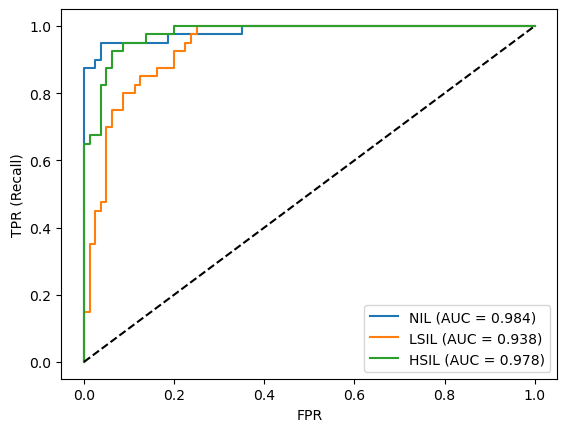

In [26]:
# Curva AUC
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

abmil.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for X, y in testing_dataloader:
        X = X.to(device)
        probs = torch.softmax(abmil(X), dim=1)
        all_probs.append(probs.cpu())
        all_labels.append(y)

probs = torch.cat(all_probs).numpy()      # (N, 3)
labels = torch.cat(all_labels).numpy()    # (N,)

classes = ['NIL', 'LSIL', 'HSIL']

for i, nome in enumerate(classes):
    fpr, tpr, _ = roc_curve((labels == i).astype(int), probs[:, i])
    plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--')           # classificador aleatório
plt.xlabel('FPR')
plt.ylabel('TPR (Recall)')
plt.legend()
plt.show()